# Coronagraph Optimization with an Interior-Point Linear Program
The bulk of amplitude-apodized coronagraph design comes from framing the apodized pupil lyot coronagraph (APLC) problem as a linear program. Because every propagation in a standard APLC is linear, the dark hole electric field is an affine function of the apodizer vector $x$. Said mathematically,

$$E_{dark hole} = Ax + b,$$

Where $E_dh$ is a vector of length $M$, $x$ and $b$ are vectors of length $N$, and $A$ is a matrix of shape $M \times N$. Constrained optimization can be achieved by maximizing throughput subject to the following box constraints:

> $|Re\{E \}| \leq \sqrt{C_{target}}$ for $x \in [0, 1]$

> $|Im\{E \}| \leq \sqrt{C_{target}}$ for $x \in [0, 1]$

Where this differs from the algorithmic differentiation method of coronagraph design is _memory_ and _convergence_. The $A$ matrix is dense, and can require gigabytes of memory to store to get started with the optimization. This procedure also finds a globally optimal solution, rather than the inherent "local" minimization accomplished using algorithmic differentiation.

The [companion how-to](OptimizingCoronagraphsLinearProgram.ipynb) hands this program to `scipy`'s HiGHS solver, which is a simplex code that runs on the CPU. In this explanation, we solve the same program with `dygdug`'s own solver, `dygdug.optimizers.linprog`, which is an interior-point method that shares the `prysm` backend. The optics, the affine model, and the feasibility checks are identical. The only thing that changes is who solves the linear program, which in this case, is `dygdug`. 

## Instrument setup
We begin by setting up a simple lyot coronagraph. Everything below is written against `prysm`'s backend-following `np`, so the notebook runs unmodified on the CPU -- delete the `set_backend_to_cupy()` call and only the timings change.

In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from time import perf_counter

from prysm.mathops import np, set_backend_to_cupy
from prysm.propagation import prepare_executor

from dygdug.backend import active_backend, asnumpy
from dygdug.masks import Pupil, FPM, ImgSamplingSpec, annular_mask, knife_edge_mask
from dygdug.coropt import VariablePupil
from dygdug.models import Coronagraph

# dygdug's linprog runs on whichever backend prysm is using; this one line is
# the difference between a CPU solve and a GPU solve.
set_backend_to_cupy()

# Define instrument parameters
circumscribed_diameter = 10.95e3
Npup = 256
Nfoc = 128
wvl = 1.0  # microns
fno = 13.66
iwa = 3
owa = 5
efl = fno * circumscribed_diameter
lamD = wvl / circumscribed_diameter * efl
px_per_lamD = 4  # the "oversampling"

/home/jarenashcraft/anaconda3/envs/prysm_test/lib/python3.10/site-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


In [2]:
# Variable (amplitude-apodized) entrance pupil
pupil = VariablePupil.annular(
    Dpup=circumscribed_diameter,
    Npup=Npup,
    inner_radius=0.1 * circumscribed_diameter / 2,
    outer_radius=1.0 * circumscribed_diameter / 2,
    mode="amplitude"
)

executor = prepare_executor(
    pupil_dx=circumscribed_diameter / Npup,
    pupil_samples=Npup,
    focal_dx=lamD / px_per_lamD,
    focal_samples=Nfoc,
    wavelength=wvl,
    efl=efl,
    focal_shift=(0, 0),
    kind="mdft",
)

fpm = FPM.annular(
    N=Nfoc,
    lamD=lamD,
    px_per_lamD=px_per_lamD,
    inner_radius=3,
    outer_radius=8,
)

lyot = Pupil.annular(
    Dpup=circumscribed_diameter,
    Npup=Npup,
    inner_radius=0.1 * circumscribed_diameter / 2,
    outer_radius=0.8 * circumscribed_diameter / 2,
)

coro = Coronagraph(pupil=pupil, fpm=fpm, lyot_stop=lyot, executor=executor)

## Optimization feasibility
Before conducting the optimization, an important check is to understand the set of the problem. For $M$ dark-hole pixels there are $4M$ inequality rows to account for the electric field constraints. For a feasible convergence, you want

$$N \gg 4M$$

In other words, you want many more apodizer pixels than you have electric field constraints. This ratio also sets the per-iteration cost of the interior-point solve: each iteration factors a dense $4M \times 4M$ matrix, so rows are the expensive dimension and columns are nearly free.

In [3]:
iss = ImgSamplingSpec(Nfoc, px_per_lamD, lamD=lamD)
dark_hole = annular_mask(iss, iwa=iwa, owa=owa, theta_min=-90, theta_max=90)

dh_idx = np.flatnonzero(np.asarray(dark_hole).astype(bool).ravel())
pup_idx = pupil._mask_idx
n = pupil.n_params  # optimizable pupil pixels
m = dh_idx.size     # constrained dark-hole pixels

contrast_req = 1e-8

print(f"n = {n} pupil pixels, m = {m} dark-hole pixels -> 4m = {4*m} constraint rows")
print(f"n / 4m = {n / (4*m):.1f}  (want >> 1)")

n = 50920 pupil pixels, m = 584 dark-hole pixels -> 4m = 2336 constraint rows
n / 4m = 21.8  (want >> 1)


## Constructing the affine transform
The `coronagraph.reverse` method that returns the adjoint of the forward model yields the method required to seed the propagation. We apply a unit impluse to a dark hole pixel and store the gradient at each row of $A$. This builds the $A$ matrix in $M$ reverse propagations (which cost $\approx 2$ forward propagations).

The offset $b$ is computed from any samples in the pupil without unit or zero transmission that are not optimized. In this example, that arises from anti-aliased pixels on the array.

Because `dygdug`'s `linprog` consumes backend arrays directly, the optimization problem and all associated arrays live on the GPU. We construct the model on an NVIDIA RTX 4090; the same cell takes about a second on an AMD Ryzen 7 9800X. Unless we are dealing with high sampling in the pupil and focal plane, there won't be significant gains here (though its already about 4x faster).

In [4]:
from tqdm import tqdm
t0 = perf_counter()
A = np.empty((m, n), dtype=complex)
Ebar = np.zeros((Nfoc, Nfoc), dtype=complex)
for k, i in tqdm(enumerate(dh_idx)):
    Ebar.ravel()[i] = 1.0
    coro.reverse(Ebar, wvl, include_fpm=True)
    A[k] = np.conj(coro.adjoint_at_entrance_pupil.ravel()[pup_idx])
    Ebar.ravel()[i] = 0.0

# Return propagation time
print(f"Jacobian ({m} adjoint propagations): {perf_counter()-t0:.1f} s, "
      f"{A.nbytes/1e6:.0f} MB on the {active_backend().__name__} backend")

# Offset from the frozen (anti-aliased rim) pixels: the field with x = 0.
pupil.update(np.zeros(n))
b = coro.forward(wvl, include_fpm=True).ravel()[dh_idx].copy()

# Contrast normalization: direct (no-FPM) peak of the open pupil.
pupil.update(np.ones(n))
norm = float(np.max(np.abs(coro.forward(wvl, include_fpm=False)) ** 2))

584it [00:00, 1866.00it/s]


Jacobian (584 adjoint propagations): 0.3 s, 476 MB on the cupy backend


We can then test the affine model against the real propagator to ensure that the constructed linearization is correct

In [5]:
# Verify E_dh = A x + b against the real propagator.
rng = np.random.default_rng(0)
x_test = rng.uniform(0, 1, n)
pupil.update(x_test)
E_ref = coro.forward(wvl, include_fpm=True).ravel()[dh_idx]
err = float(np.max(np.abs(A @ x_test + b - E_ref)) / np.max(np.abs(E_ref)))
print(f"affine model max relative error: {err:.1e}")
assert err < 1e-12, "affine model does not match the propagator"

affine model max relative error: 2.2e-15


Before conducting the solve, we can provide a final check that the design can be binary at the given contrast. For a given pixel in the apodizer, a change from 0 to 1 will alter the focal plane by the associated column in the Jacobian, $A$. We refer to this as the _field quantum_. A binary APLC creates the dark hole out of a selection of these quanta, so the amplitude budget $s = \sqrt{C_{target} / 2}$ must be several times this field quantum.

In [6]:
s_req = float(np.sqrt(contrast_req / 2))
quantum = np.abs(A) / np.sqrt(norm)  # per-pixel amplitude quantum, normalized
q_max, q_med = float(quantum.max()), float(np.median(quantum))

print(f"amplitude budget s: {s_req:.1e}")
print(f"pixel field quantum: max {q_max:.1e}, median {q_med:.1e}")
print(f"s / max quantum: {s_req / q_max:.1f}  (want >~ 3)")

amplitude budget s: 7.1e-05
pixel field quantum: max 3.9e-05, median 1.9e-05
s / max quantum: 1.8  (want >~ 3)


## Assemble and solve the linear program
Normalizing by the direct image peak, we construct the bounds for the $A$ and $b$ parts of the affine transform that maximize throughput. Here, the throughput maximization is achieved by providing `linprog` with a vector of `-1`. This turns the minimization into a maximization of the pixel values, which is a proxy for core throughput.

Two things are missing relative to the `scipy` call: there is no `method=` argument, because the module implements exactly one method, and there is no `bounds=` argument, because `dygdug`'s `linprog` defaults to the apodizer box $0 \leq x \leq 1$.

In [7]:
from dygdug.optimizers import linprog

rn = 1 / np.sqrt(norm)
M, boff = A * rn, b * rn
A_ub = np.vstack([M.real, -M.real, M.imag, -M.imag])
b_ub = s_req + np.concatenate([-boff.real, boff.real, -boff.imag, boff.imag])
print(f"LP: {A_ub.shape[0]} rows x {A_ub.shape[1]} cols ({A_ub.nbytes/1e6:.0f} MB)")

t0 = perf_counter()
res = linprog(-np.ones(n), A_ub=A_ub, b_ub=b_ub)  # verbose=True prints the residuals
print(f"solve: {perf_counter()-t0:.0f} s, {res.iterations} iterations, "
      f"status {res.status}, {res.message}")
print(f"duality gap {res.duality_gap:.1e}, primal residual {res.primal_residual:.1e}")
assert res.status == 0, "infeasible: this contrast is unreachable for this geometry"

x_lp = res.x.copy()
tol = 1e-6  # an interior-point iterate approaches the bounds, it never lands on them
x_lp[x_lp <= tol] = 0.0
x_lp[x_lp >= 1 - tol] = 1.0
frac = np.flatnonzero((x_lp > 0) & (x_lp < 1))
fuzz = np.flatnonzero((res.x > 1e-9) & (res.x < 1 - 1e-9))

print(f"throughput (mean transmission): {float(x_lp.mean()):.4f}")
print(f"fractional pixels: {frac.size}/{n} ({frac.size/n:.2%}); LP bound was {4*m}")
print(f"pixels off a bound by more than 1e-9: {fuzz.size} ({fuzz.size/n:.2%})")

LP: 2336 rows x 50920 cols (952 MB)
solve: 41 s, 78 iterations, status 0, converged
duality gap 7.3e-06, primal residual 1.4e-13
throughput (mean transmission): 0.8510
fractional pixels: 128/50920 (0.25%); LP bound was 2336
pixels off a bound by more than 1e-9: 7786 (15.29%)


## Interior point versus simplex
The two solvers return the same optimum -- mean transmission 0.8510 either way, with the objectives agreeing to seven digits.

HiGHS is a simplex code. It walks the vertices of the feasible polytope, and the point it returns _is_ a vertex, so at most $4M$ entries can be fractional and the rest sit exactly on 0 or 1. 

`dygdug.optimizers.linprog` implements Mehrotra's predictor-corrector method. It stays strictly inside the box and drives the complementarity gap to zero from within, and every iteration is the same three dense operations: one GEMM to form the normal-equations matrix $A D^{-1} A^T$, one Cholesky factorization of it, and a pair of triangular solves. That matrix is $4M \times 4M$ so the GEMM dominates, which GPUs are pretty good at. The solve above took 41 s on the RTX 4090; the identical call on the CPU backend takes 114 s, against 87 s for HiGHS, which calls compiled C code. This is an example of pure Python with a `cupy` backend outperforming a compiled library, made possible by how good GPUs are at matrix multiplications.

The cost is the vertex property. An interior-point method converges to the analytic center of the optimal face, not to a corner of it, so:

- "Binary" pixels are binary only to solver tolerance. At a `1e-9` threshold 15% of the pupil still looks gray; at `1e-6` 0.25% does. The scale of the fuzz is set by `tol`, not by the physics.
- Sitting at the center of the optimal face is not always a cost. The field box is a square in the complex plane, and a vertex solution parks the worst dark-hole pixels on its corners, where $|E|^2 = 2s^2 = C_{target}$. The interior-point design lands mid-face instead, and comes out a factor of two darker than the requirement for free, as the plot below shows.

Use HiGHS when you want a certified vertex and the problem fits comfortably on the CPU. Use `dygdug.optimizers.linprog` when the constraint matrix is large enough that you want the GEMM on a GPU, or if you simply prefer to work with a stack that is entirely `dygdug` and `prysm`. The knobs are `tol` (all three optimality measures), `max_iter` (each iteration is one GEMM plus one Cholesky), `verbose=True` to watch the residuals fall, and `x0` to warm start, which helps an interior-point method less than it helps simplex.

## AI Useage Disclosure
The implementation of Mehrotra's predictor-corrector method was developed using Claude Fable 5, and was not implemented by hand by the author. Before adding to `dygdug`, we benchmarked the solutions for circular apertures against `scipy.linprog` to find that they converge on the same solution.

## Plot the apodizer solution
We observe an almost completely binary apodizer (0.25% of pixels are gray) that produces a $10^{-8}$ dark zone. Going to deeper contrasts requires more field quantum, which requires more apodizer and focal plane pixels, which in turn requires more memory. Solving for the full apodizer results in this quickly becoming a problem that requires terabytes of RAM -- and on a GPU the memory wall arrives sooner, since the constraint matrix and one working copy of it have to fit in device memory. However, leveraging symmetries in the optical system can reduce the dimensionality of the problem by a great deal. Also, using low-resolution starting points that seed the progressive refinement of coronagraph designs can work a solution toward high resolution. These will be explored in a future how-to.

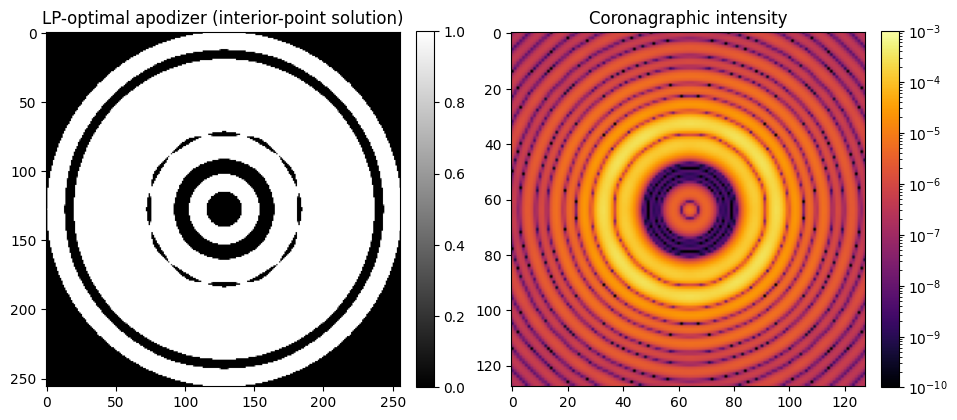

LP design dark-hole max contrast: 5.00e-09 (requirement 1e-08)


In [8]:
pupil.update(x_lp)
I_lp = np.abs(coro.forward(wvl, include_fpm=True)) ** 2 / norm

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].set_title("LP-optimal apodizer (interior-point solution)")
im0 = ax[0].imshow(asnumpy(pupil.data), cmap="gray", vmin=0, vmax=1)
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
ax[1].set_title("Coronagraphic intensity")
im1 = ax[1].imshow(asnumpy(I_lp), cmap="inferno", norm=LogNorm(vmin=1e-10, vmax=1e-3))
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
plt.show()

print(f"LP design dark-hole max contrast: {float(I_lp.ravel()[dh_idx].max()):.2e} "
      f"(requirement {contrast_req:.0e})")